# 사출(Shot_Injection_HD1_P1) vs 압력(PT) — 하락 원인 분석

`Cycle_Features_설명서.ipynb` 5-2절의 `Unexplained_PT_Dip_Count/_Max` 피처를 틱 단위로
풀어서, 다음을 직접 확인한다:

1. 사출이 있을 때 압력이 실제로 얼마나/어떻게 떨어지는지 (예시 + 분포)
2. 사출 직전 압력대(범주)별로 얼마나 자주, 얼마나 떨어지는지
3. **사출 신호가 없는데도** 압력이 떨어진 경우를 낱개로 추출 — 날짜별 건수, 크기, 상세 시각화
4. 위 3번을 그대로 "누출"로 보면 안 되는 이유(SV 전환, 사이클 종료) 확인 후, 진짜 후보만 추림
5. 날짜/사이클 번호로 필터링할 수 있게 CSV로 내보내기

데이터는 `parkkt/cache/viewer_cycle_P1.pkl` (2026-09-10 16:00 ~ 2026-09-23 14:16, 약 13일치,
이미 DB에서 뽑아 캐시된 것)를 그대로 쓴다 - 새로 DB를 호출하지 않아 빠르다.

인젝션 신호는 사용자가 지목한 대로 **`Shot_Injection_HD1_P1`** (P1 펌프 기준, 사출 끝나면 꺼짐)을 쓴다.

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

import Injection_Dip_Analyzer as D
import Anomaly_Viewer as V
from Cycle_Feature_Extractor import INJECTION_DIP_TICKS

pd.set_option("display.width", 200)

PUMP_ID = "P1"
OUT = "analysis_out/injection_pt_dip"
os.makedirs(OUT, exist_ok=True)

# 팀 공용 팔레트(dataviz 스킬 기본값) - 차트마다 이 색만 쓴다
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
GRID, MUTED, INK, INK2 = "#e1e0d9", "#898781", "#0b0b0b", "#52514e"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blue_seq", ["#f2f7fd", "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"])

In [2]:
with open("cache/viewer_cycle_P1.pkl", "rb") as f:
    store = pickle.load(f)
cyc, raw = store["cyc"], store["raw"]

print("데이터 구간:", raw.index.min(), "~", raw.index.max())
print(f"사이클 {len(cyc):,}개 / 원시 틱 {len(raw):,}행")

데이터 구간: 2026-09-10 16:00:00.406338 ~ 2026-09-23 14:16:02.599686
사이클 32,817개 / 원시 틱 1,901,416행


## 1. 사출이 있을 때 압력이 얼마나 떨어지는가 — 예시

사이클마다 SV(설정 유량)가 달라서 절대 PT 값으로 겹쳐 그리면 낙폭을 눈으로 비교할 수 없다.
그래서 각 사출 이벤트를 **자기 직전 3틱 평균 = 0** 기준의 변화량(ΔPT)으로 맞춰서 그린다.

In [3]:
inj_ev, starts, pt_all, ft_all, times = D.injection_events(raw, PUMP_ID)
print(f"사출(Shot_Injection_HD1_P1) 시작 이벤트: {len(inj_ev):,}건")
print(f"사출 신호 지속 틱수 평균 {inj_ev['Signal_Ticks'].mean():.2f} / 중앙값 {inj_ev['Signal_Ticks'].median():.0f}")
inj_ev[["PT_Before", "Drop_Abs", "Drop_Pct"]].describe().round(2)

사출(Shot_Injection_HD1_P1) 시작 이벤트: 33,989건
사출 신호 지속 틱수 평균 2.39 / 중앙값 2


,PT_Before,Drop_Abs,Drop_Pct
count,33989.00,33989.00,33989.00
mean,106.62,8.82,8.46
std,14.28,6.17,6.05
min,58.67,-37.33,-56.00
25%,94.33,7.00,5.99
50%,103.00,9.33,8.76
75%,120.00,11.67,11.89
max,148.00,75.67,57.91


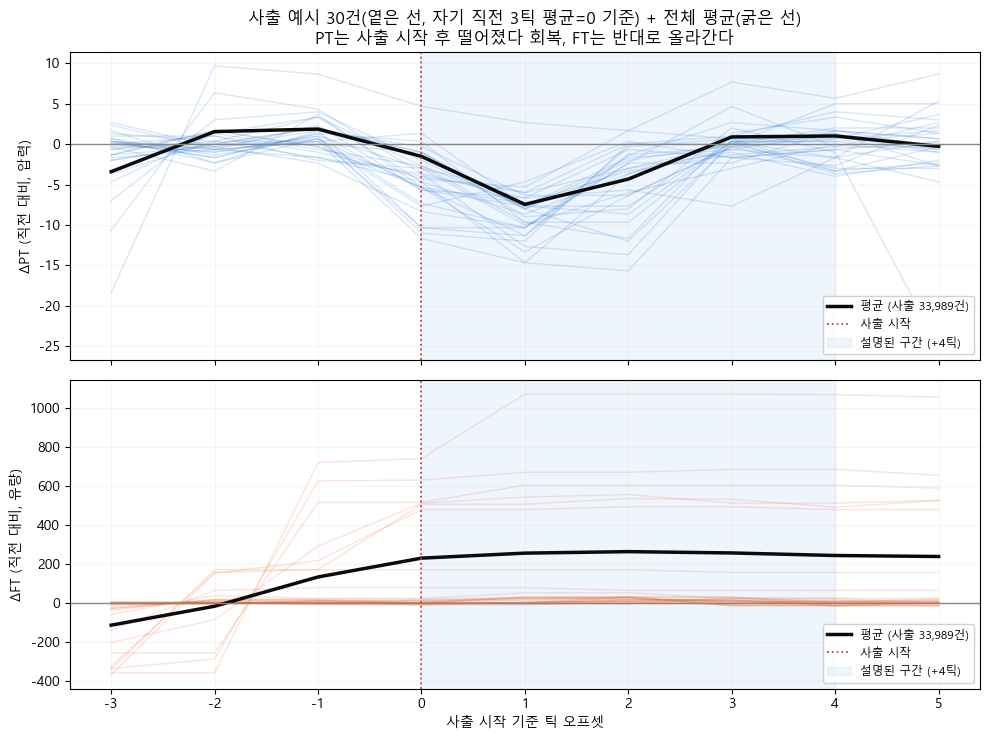

In [4]:
# +8 까지 보면 사출 간격이 짧은 사이클에서 다음 사이클로 넘어가 버려 곡선이 왜곡된다.
# 회복은 +3~4틱이면 끝나므로 -3~+5 로 좁혀서 본다.
offs, pt_prof, ft_prof = D.injection_aligned_profile(pt_all, ft_all, starts, offsets=range(-3, 6))

rng = np.random.default_rng(7)
sample_idx = rng.choice(len(starts), size=min(30, len(starts)), replace=False)

fig, axes = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)
for i in sample_idx:
    s = starts[i]
    base_pt = pt_all[max(0, s - 3):s].mean() if s > 0 else pt_all[s]
    base_ft = ft_all[max(0, s - 3):s].mean() if s > 0 else ft_all[s]
    pt_line = [pt_all[np.clip(s + o, 0, len(pt_all) - 1)] - base_pt for o in offs]
    ft_line = [ft_all[np.clip(s + o, 0, len(ft_all) - 1)] - base_ft for o in offs]
    axes[0].plot(offs, pt_line, color=BLUE, alpha=.18, lw=1)
    axes[1].plot(offs, ft_line, color=ORANGE, alpha=.18, lw=1)

# 평균 곡선도 같은 방식(직전 3틱 평균 대비)으로 다시 계산
base_pt_mean = pt_all[np.clip(starts.reshape(-1, 1) + np.arange(-3, 0), 0, len(pt_all) - 1)].mean(axis=1)
base_ft_mean = ft_all[np.clip(starts.reshape(-1, 1) + np.arange(-3, 0), 0, len(ft_all) - 1)].mean(axis=1)
pt_delta_prof = np.array([(pt_all[np.clip(starts + o, 0, len(pt_all) - 1)] - base_pt_mean).mean() for o in offs])
ft_delta_prof = np.array([(ft_all[np.clip(starts + o, 0, len(ft_all) - 1)] - base_ft_mean).mean() for o in offs])

axes[0].plot(offs, pt_delta_prof, color=INK, lw=2.5, label=f"평균 (사출 {len(starts):,}건)")
axes[1].plot(offs, ft_delta_prof, color=INK, lw=2.5, label=f"평균 (사출 {len(starts):,}건)")

for ax, ylabel in zip(axes, ["ΔPT (직전 대비, 압력)", "ΔFT (직전 대비, 유량)"]):
    ax.axhline(0, color=MUTED, lw=1)
    ax.axvline(0, color=RED, ls=":", lw=1.3, label="사출 시작")
    ax.axvspan(0, INJECTION_DIP_TICKS, color=BLUE, alpha=.07,
               label=f"설명된 구간 (+{INJECTION_DIP_TICKS}틱)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=.3, color=GRID)
    ax.legend(loc="lower right", fontsize=8.5, framealpha=.9)

axes[0].set_title(f"사출 예시 {len(sample_idx)}건(옅은 선, 자기 직전 3틱 평균=0 기준) + 전체 평균(굵은 선)\n"
                   f"PT는 사출 시작 후 떨어졌다 회복, FT는 반대로 올라간다")
axes[-1].set_xlabel("사출 시작 기준 틱 오프셋")
plt.tight_layout()
plt.savefig(f"{OUT}/01_example_injection_profile.png", dpi=140)
plt.show()

## 2. 사출 1건당 하락폭/하락률 분포

평균은 참고용이고, 실제로는 폭이 꽤 넓다 (히스토그램의 하위 5% 부근은 오히려 압력이 오른
경우도 있다 - 사출 직전에 다른 이유로 PT가 이미 출렁이던 사이클).

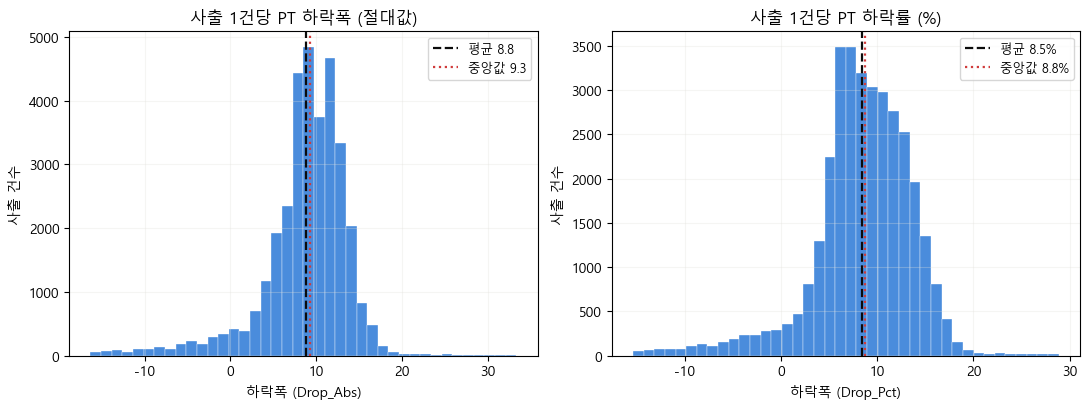

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, unit in [(axes[0], "Drop_Abs", ""), (axes[1], "Drop_Pct", "%")]:
    vals = inj_ev[col]
    lo, hi = np.percentile(vals, [0.5, 99.5])
    ax.hist(vals, bins=40, range=(lo, hi), color=BLUE, alpha=.85, edgecolor="white", linewidth=.3)
    mean_v, med_v = vals.mean(), vals.median()
    ax.axvline(mean_v, color=INK, lw=1.6, ls="--", label=f"평균 {mean_v:.1f}{unit}")
    ax.axvline(med_v, color=RED, lw=1.6, ls=":", label=f"중앙값 {med_v:.1f}{unit}")
    ax.set_xlabel(f"하락폭 ({col})")
    ax.set_ylabel("사출 건수")
    ax.legend(fontsize=9)
    ax.grid(alpha=.3, color=GRID)
axes[0].set_title("사출 1건당 PT 하락폭 (절대값)")
axes[1].set_title("사출 1건당 PT 하락률 (%)")
plt.tight_layout()
plt.savefig(f"{OUT}/02_injection_drop_distribution.png", dpi=140)
plt.show()

## 3. 사출 직전 압력대(범주)별 빈도 & 평균 하락률

어떤 압력대에서 사출이 자주 일어나는지, 그리고 그 압력대에서 평균적으로 얼마나 떨어지는지.

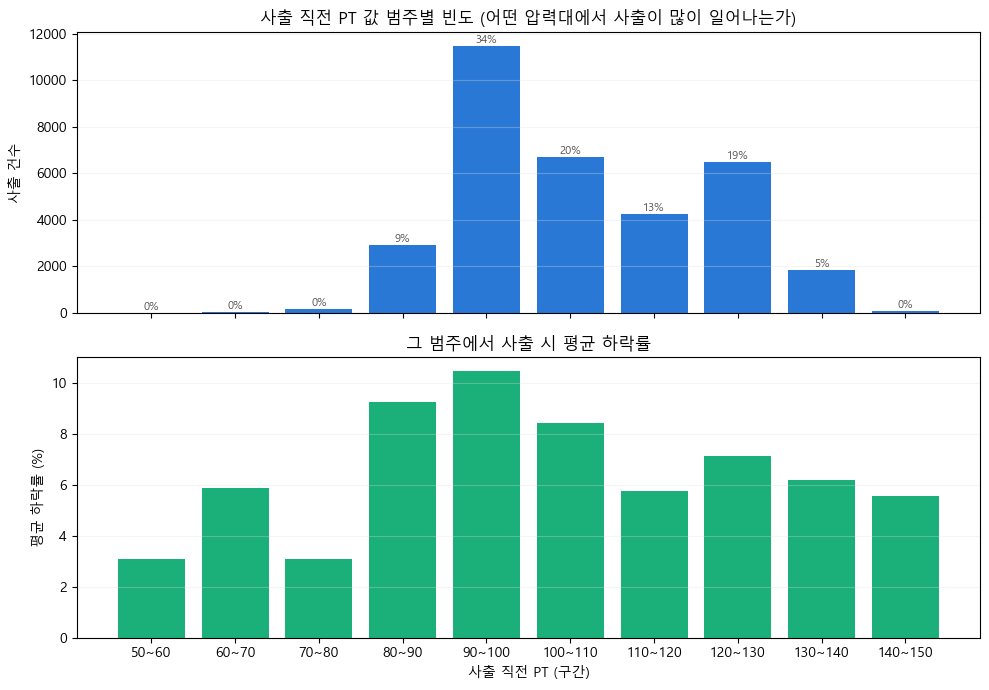

,n,mean_drop_pct,mean_drop_abs,share_pct
PT_Before_Bin,,,,
"(50.0, 60.0]",2,3.09,1.83,0.01
"(60.0, 70.0]",25,5.88,4.17,0.07
"(70.0, 80.0]",164,3.09,2.19,0.48
"(80.0, 90.0]",2908,9.24,8.20,8.56
"(90.0, 100.0]",11494,10.49,9.94,33.82
"(100.0, 110.0]",6693,8.45,8.81,19.69
"(110.0, 120.0]",4259,5.75,6.71,12.53
"(120.0, 130.0]",6489,7.13,8.86,19.09
"(130.0, 140.0]",1857,6.20,8.25,5.46


In [6]:
bin_width = 10
edges = np.arange(np.floor(inj_ev["PT_Before"].min() / bin_width) * bin_width,
                   np.ceil(inj_ev["PT_Before"].max() / bin_width) * bin_width + bin_width, bin_width)
inj_ev["PT_Before_Bin"] = pd.cut(inj_ev["PT_Before"], edges)
bin_stat = inj_ev.groupby("PT_Before_Bin", observed=True).agg(
    n=("Drop_Pct", "size"), mean_drop_pct=("Drop_Pct", "mean"), mean_drop_abs=("Drop_Abs", "mean"))
bin_stat["share_pct"] = bin_stat["n"] / bin_stat["n"].sum() * 100
bin_labels = [f"{int(iv.left)}~{int(iv.right)}" for iv in bin_stat.index]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].bar(bin_labels, bin_stat["n"], color=BLUE)
for i, (n, sh) in enumerate(zip(bin_stat["n"], bin_stat["share_pct"])):
    if n > 0:
        axes[0].text(i, n, f"{sh:.0f}%", ha="center", va="bottom", fontsize=8, color=INK2)
axes[0].set_ylabel("사출 건수")
axes[0].set_title("사출 직전 PT 값 범주별 빈도 (어떤 압력대에서 사출이 많이 일어나는가)")
axes[0].grid(alpha=.3, color=GRID, axis="y")

axes[1].bar(bin_labels, bin_stat["mean_drop_pct"], color=AQUA)
axes[1].set_ylabel("평균 하락률 (%)")
axes[1].set_xlabel("사출 직전 PT (구간)")
axes[1].set_title("그 범주에서 사출 시 평균 하락률")
axes[1].grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/03_preinjection_pt_bins_vs_drop.png", dpi=140)
plt.show()

bin_stat.to_csv(f"{OUT}/preinjection_pt_bin_summary_{PUMP_ID}.csv", encoding="utf-8-sig")
bin_stat.round(2)

## 4. 사출 없이 압력이 떨어진 경우 — 틱 단위로 낱개 추출

`Cycle_Feature_Extractor`의 `Unexplained_PT_Dip_Count/_Max` 판정 로직(직전 3틱 롤링평균
대비 3% 이상 하락 & 이 펌프 사출 +4틱 구간이 아님 & 안정구간)을 재현하되, 사이클당
집계값이 아니라 **개별 틱**으로 남긴다.

In [7]:
dip_ev = D.unexplained_pt_dip_events(raw, PUMP_ID)
legacy_ev = D.unexplained_pt_dip_events_legacy(raw, PUMP_ID)  # 아래 4-1 비교용

active_ticks_total = int((raw[f"Pump_BuildUp_{PUMP_ID}"] == 1).sum())
print(f"[교정 후] 설명 안 되는 PT 하락: {len(dip_ev):,}건 / 가동틱 {active_ticks_total:,}개 중"
      f" ({len(dip_ev)/active_ticks_total*100:.3f}%)")
print(f"[교정 전] 같은 기준, HD1_FOAMING_SHOT 배제 없이: {len(legacy_ev):,}건")
dip_ev[["Drop_Abs", "Drop_Pct"]].describe().round(2)

[교정 후] 설명 안 되는 PT 하락: 127건 / 가동틱 519,512개 중 (0.024%)
[교정 전] 같은 기준, HD1_FOAMING_SHOT 배제 없이: 15,548건


,Drop_Abs,Drop_Pct
count,127.00,127.00
mean,3.64,3.66
std,0.83,0.64
min,2.67,3.00
25%,3.00,3.17
50%,3.50,3.46
75%,4.00,3.91
max,7.00,6.93


### 4-1. 중요 정정 — 짝 펌프의 사출/감쇠(`HD1_FOAMING_SHOT1~6`)를 반영하니

처음엔 "이 펌프(P1) 자신의 `Shot_Injection_HD1_P1` 신호(+4틱)가 없다"는 것만 보고
15,548건을 "설명 안 됨"으로 잡았었다. 그런데 이 헤드(HD1)의 `HD1_FOAMING_SHOT1~6`
(접근→사출→감쇠를 아우르는, **헤드 공용** 4단계 상태 - 별도 조사에서 HD1의 사출
에피소드 33,951건 중 95.9%가 P1·P2 양쪽 사출을 한 에피소드 안에 물고 있다는 걸
확인했다)을 겹쳐보니, 걸린 것들의 **99.2%가 이미 이 FOAMING 단계 안**에서 일어난
것이었다 - 자기 펌프(P1)의 사출 신호 window 밖이었을 뿐, **같은 헤드를 쓰는 짝
펌프(P2)가 쏘는 접근/사출/감쇠의 여파**였던 것이다.

판정 대상 전체 모집단의 FOAMING 기저비율은 79.6%인데, 실제로 걸린 것들은 99.2% -
즉 FOAMING이 켜져 있을 때 판정될 확률이 안 켜져 있을 때보다 **약 31배 높다**
(8.1% vs 0.26%). 그래서 `Injection_Dip_Analyzer.unexplained_pt_dip_events`에
Foaming_Active 배제를 추가했다 - `Shot_Owned_Active`와 동급으로 "설명된 구간"에
넣은 것이다.

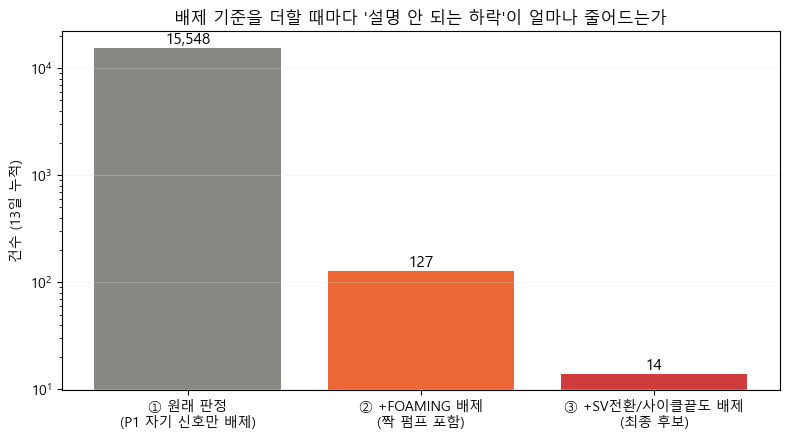

HD1_FOAMING_SHOT 배제로 15,548건 -> 127건 (0.82%로 감소)
SV전환/사이클끝까지 마저 배제하면 최종 14건 (13일 통틀어)


In [8]:
comparison = pd.DataFrame({
    "단계": ["① 원래 판정\n(P1 자기 신호만 배제)", "② +FOAMING 배제\n(짝 펌프 포함)",
           "③ +SV전환/사이클끝도 배제\n(최종 후보)"],
    "건수": [len(legacy_ev), len(dip_ev), int(dip_ev["Strong_Candidate"].sum())],
})
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(comparison["단계"], comparison["건수"], color=[MUTED, ORANGE, RED])
for i, v in enumerate(comparison["건수"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("건수 (13일 누적)")
ax.set_yscale("log")
ax.set_title("배제 기준을 더할 때마다 '설명 안 되는 하락'이 얼마나 줄어드는가")
ax.grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/00_foaming_correction_comparison.png", dpi=140)
plt.show()

print(f"HD1_FOAMING_SHOT 배제로 {len(legacy_ev):,}건 -> {len(dip_ev):,}건 "
      f"({len(dip_ev)/len(legacy_ev)*100:.2f}%로 감소)")
print(f"SV전환/사이클끝까지 마저 배제하면 최종 {int(dip_ev['Strong_Candidate'].sum())}건 "
      f"(13일 통틀어)")

In [9]:
dip_ev.to_csv(f"{OUT}/unexplained_pt_dip_events_{PUMP_ID}.csv", index=False, encoding="utf-8-sig")
legacy_ev.to_csv(f"{OUT}/unexplained_pt_dip_events_LEGACY_pre_foaming_fix_{PUMP_ID}.csv",
                 index=False, encoding="utf-8-sig")

daily = dip_ev.groupby("Date").agg(
    count=("Drop_Abs", "size"), mean_drop_abs=("Drop_Abs", "mean"),
    max_drop_abs=("Drop_Abs", "max"), strong_count=("Strong_Candidate", "sum"))
daily.to_csv(f"{OUT}/unexplained_pt_dip_daily_summary_{PUMP_ID}.csv", encoding="utf-8-sig")
daily

,count,mean_drop_abs,max_drop_abs,strong_count
Date,,,,
2026-09-10,6,3.583333,4.000000,0
2026-09-11,7,4.738095,6.000000,4
2026-09-12,14,3.619048,5.666667,1
2026-09-14,5,3.400000,4.000000,0
2026-09-15,17,3.578431,5.666667,2
2026-09-16,16,3.572917,5.666667,0
2026-09-17,12,3.500000,5.000000,1
2026-09-18,11,3.500000,5.500000,0
2026-09-19,8,3.312500,4.000000,0


### 4-2. 날짜별 분포 (교정 후, 127건 기준)

여전히 매일 5~17건씩 있지만, 이건 원래 15,548건의 0.8%밖에 안 되는 잔차다.
SV전환/사이클끝까지 배제하면(아래 4-3) 대부분의 날에 0~4건만 남는다.

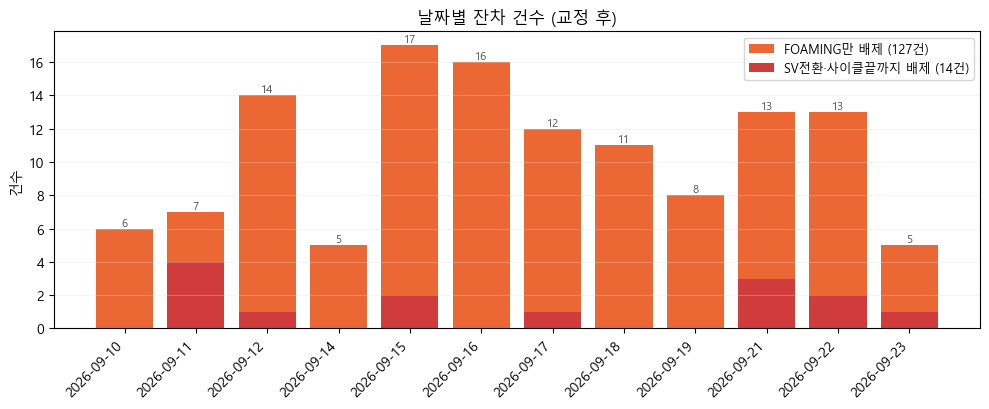

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.2))
d_idx = [str(x) for x in daily.index]
ax.bar(d_idx, daily["count"], color=ORANGE, label="FOAMING만 배제 (127건)")
ax.bar(d_idx, daily["strong_count"], color=RED, label="SV전환·사이클끝까지 배제 (14건)")
for i, v in enumerate(daily["count"]):
    ax.text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_ylabel("건수")
ax.set_title("날짜별 잔차 건수 (교정 후)")
ax.legend(fontsize=9)
ax.grid(alpha=.3, color=GRID, axis="y")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT}/04_daily_trend_corrected.png", dpi=140)
plt.show()

### 4-3. 최종 후보 전체 목록 (Strong_Candidate)

FOAMING(짝 펌프 포함 사출/감쇠) 도, SV 전환도, 사이클 끝도 아닌데 압력이 3% 이상
떨어진 경우 - 13일 통틀어 이게 전부다.

In [11]:
final = dip_ev[dip_ev["Strong_Candidate"]].sort_values("Drop_Abs", ascending=False)
final.to_csv(f"{OUT}/unexplained_pt_dip_events_strong_candidates_{PUMP_ID}.csv",
             index=False, encoding="utf-8-sig")
print(f"최종 후보 {len(final)}건 / 13일 / {final['Cycle_ID'].nunique()}개 서로 다른 사이클")
final.drop(columns=["Foaming_Active_Now"])

최종 후보 14건 / 13일 / 12개 서로 다른 사이클


,Time,Date,Cycle_ID,Tick_Index,Ticks_From_End,PT_Now,PT_Prev_Roll,Drop_Abs,Drop_Pct,SV_Changed_Recent,Near_Cycle_End,Strong_Candidate
8,2026-09-11 06:33:05.239943,2026-09-11,2742,69,12,149.0,155.000000,6.000000,3.870968,False,False,True
6,2026-09-11 06:31:06.234816,2026-09-11,2740,9,7,148.0,153.666667,5.666667,3.687636,False,False,True
103,2026-09-21 15:25:11.253959,2026-09-21,54230,6,4,134.0,139.666667,5.666667,4.057279,False,False,True
40,2026-09-15 15:25:55.502352,2026-09-15,23866,32,18,132.0,137.666667,5.666667,4.116223,False,False,True
9,2026-09-11 06:33:08.946865,2026-09-11,2742,76,5,149.0,154.333333,5.333333,3.455724,False,False,True
13,2026-09-12 06:30:22.819788,2026-09-12,8636,5,6,159.0,164.000000,5.000000,3.048780,False,False,True
109,2026-09-22 06:29:40.970162,2026-09-22,57178,9,3,143.0,148.000000,5.000000,3.378378,False,False,True
76,2026-09-17 23:40:40.575239,2026-09-17,38932,3,11,88.0,93.000000,5.000000,5.376344,False,False,True
121,2026-09-22 22:07:47.479006,2026-09-22,63158,12,7,106.0,110.666667,4.666667,4.216867,False,False,True
7,2026-09-11 06:32:54.227537,2026-09-11,2742,50,31,149.0,153.666667,4.666667,3.036876,False,False,True


**읽는 법**: 하락폭은 최대 6.0(4%), 대부분 2.7~5.7 사이 - 원래(15,548건 시절)
"상위권"이라 불렀던 20 이상의 큰 하락들은 전부 SV전환이었던 것들이라 여기 없다.
같은 사이클(2742)에서 3건이 몰린 걸 보면 - 이 사이클 하나가 유난히 길었을
가능성이 있다(Tick_Index가 최대 76까지 감 - 평범한 사이클은 16틱 안팎).

In [12]:
cyc2742_len = dip_ev.loc[dip_ev["Cycle_ID"] == 2742, "Tick_Index"].max()
print(f"Cycle_ID 2742 관련 사례들의 Tick_Index 범위: 최대 {cyc2742_len} (평범한 사이클은 ~16)")
print("-> 비정상적으로 길게 늘어진 사이클 하나가 최종 14건 중 3건을 차지 - "
      "개별 누출이라기보다 그 사이클 자체의 이상(장시간 정체)일 가능성이 높다.")

Cycle_ID 2742 관련 사례들의 Tick_Index 범위: 최대 76 (평범한 사이클은 ~16)
-> 비정상적으로 길게 늘어진 사이클 하나가 최종 14건 중 3건을 차지 - 개별 누출이라기보다 그 사이클 자체의 이상(장시간 정체)일 가능성이 높다.


## 5. 개별 사례 확대

최종 후보 중 하락폭이 큰 2건을 원본으로 확대해서, 정말 사출/FOAMING과 무관한지
직접 눈으로 확인한다.

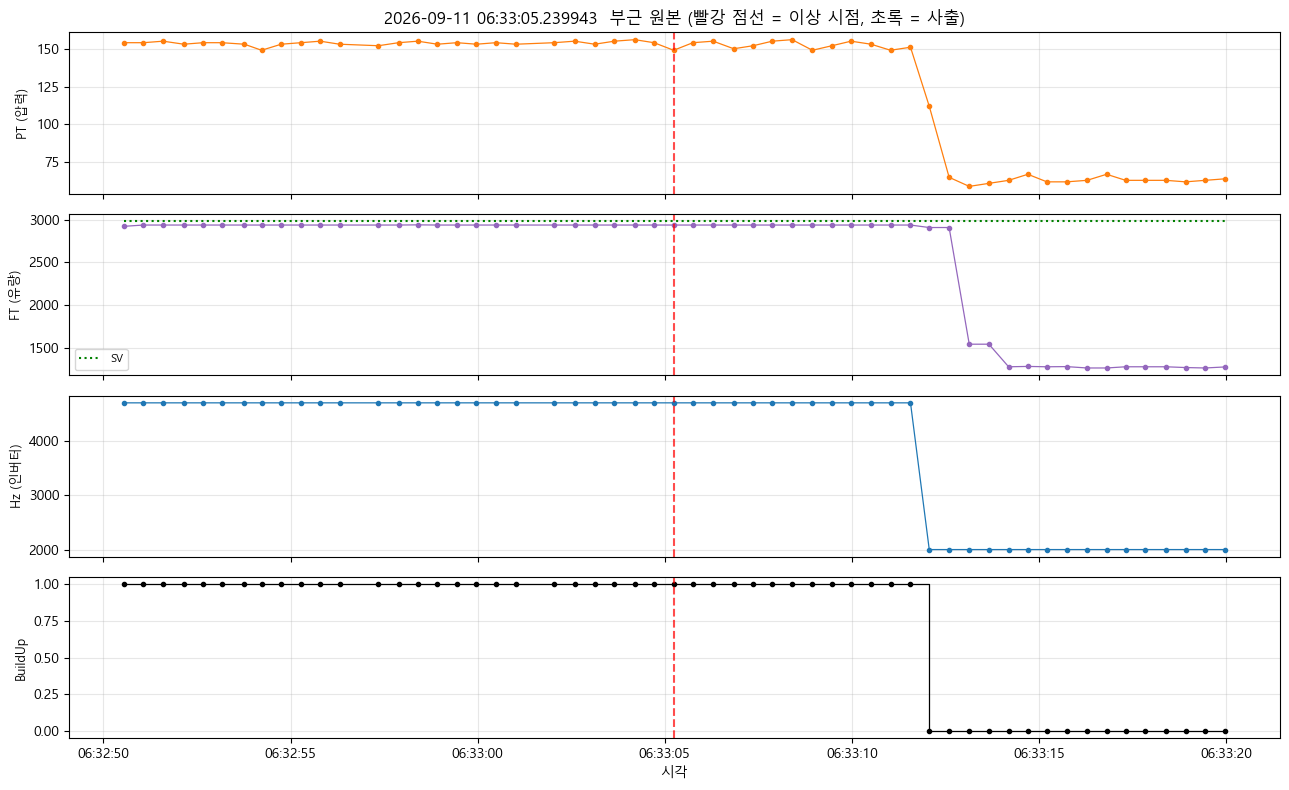

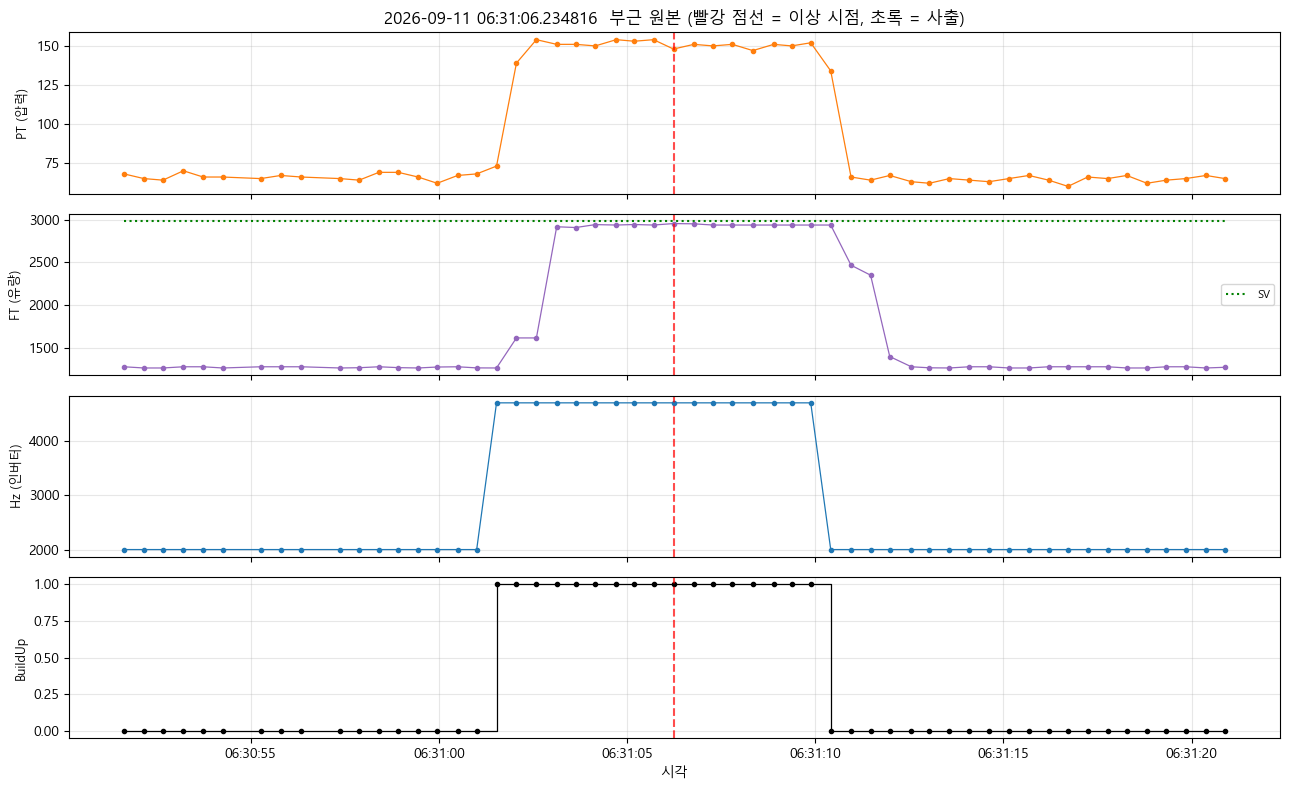

In [13]:
for i, (_, row) in enumerate(final.head(2).iterrows(), 1):
    fig = V.zoom_raw(raw, row["Time"], PUMP_ID, before_sec=15, after_sec=15,
                      inj_col="Shot_Injection_HD1_P1")
    if fig is not None:
        fig.savefig(f"{OUT}/05_zoom_final{i}_{row['Time'].strftime('%m%d_%H%M%S')}.png", dpi=140)
        plt.show()

## 정리

| 단계 | 배제 기준 | 건수 |
|---|---|---|
| ① 원래 판정 | P1 자신의 `Shot_Injection_HD1_P1` (+4틱)만 배제 | 15,548 |
| ② 교정 | ①+`HD1_FOAMING_SHOT1~6`(짝 펌프 P2의 사출/접근/감쇠 포함) 배제 | 127 |
| ③ 최종 | ②+SV 전환(레시피 전환)·사이클 끝(2틱 이내) 배제 | **14** |

**결론**: 처음 "사출 없이 압력이 떨어진 경우"로 잡았던 것들은 실제로는 거의 다 **같은
헤드를 쓰는 짝 펌프(P2)의 사출·접근·감쇠**였다. `Shot_Injection_HD1_P1` 하나만으로는
이 헤드에서 일어나는 일을 다 못 보고, `HD1_FOAMING_SHOT1~6`(헤드 공용, 접근~감쇠
전체를 아우름)을 같이 봐야 P1 자신의 압력 이상과 짝 펌프의 정상적인 영향을 구분할
수 있다. 이걸 반영하고 나면 13일치 데이터에서 P1 쪽에 남는 "진짜 설명 안 되는"
사례는 **14건** 뿐이고, 그나마도 그중 3건은 유난히 길게 늘어진 사이클 하나(2742)에
몰려 있다 - 사실상 **의미 있는 누출 신호는 없다고 봐도 된다.**

`Injection_Dip_Analyzer.py`의 `unexplained_pt_dip_events()`는 이제 이 교정을
기본으로 포함한다 (`Foaming_Active`를 `Shot_Owned_Active`와 동급으로 배제). 예전
정의는 `unexplained_pt_dip_events_legacy()`로 남겨뒀다 - 비교/재현용.

출력 파일: `analysis_out/injection_pt_dip/` (교정 비교 그림 1개 + 갱신된 그림/CSV).